### Step 1: Import Required Libraries

We import all the necessary libraries needed throughout the project:
- **pandas & numpy** — for data loading and numerical operations
- **seaborn & matplotlib** — for data visualization (plots and graphs)
- **LabelEncoder, StandardScaler** — for preprocessing (encoding labels, scaling features)
- **train_test_split** — to split data into training and testing sets
- **accuracy_score, classification_report** — to evaluate model performance
- **4 ML Models** — RandomForest, LogisticRegression, DecisionTree, GaussianNB
- **GridSearchCV** — to automatically find the best hyperparameters for each model
- **pickle** — to save the trained model to disk for later use in Flask app
- **warnings** — to suppress unnecessary warning messages during execution

In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV

import pickle
import warnings
warnings.filterwarnings('ignore')

### Step 2: Load and Inspect the Dataset

We load the crop recommendation CSV file into a pandas DataFrame.
- `df.shape` tells us the total number of rows and columns → (2200, 8)
- `df.columns` shows all feature names: N, P, K, temperature, humidity, ph, rainfall, label
- `df.head()` displays the first 5 rows to visually confirm the data loaded correctly

This is always the first step — before any processing, we verify the data is loaded as expected.

In [30]:
df = pd.read_csv('notebook\Crop_recommendation.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (2200, 8)

Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

First 5 rows:


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


### Step 3: Check Data Quality

Two important checks before preprocessing:

**1. Null Value Check (`df.isnull().sum()`)**
Missing values can cause errors during model training. We verify every column has 0 null values, confirming the dataset is clean and ready to use.

**2. Class Balance Check (`df['label'].value_counts()`)**
We check how many samples exist per crop. Result shows exactly 100 samples for each of the 22 crops (22 × 100 = 2200 total). This is a perfectly balanced dataset, meaning no crop is over or under-represented — so our model won't be biased toward any particular crop.

In [31]:
# Missing values check
print("Null values:\n", df.isnull().sum())

# Class balance check
print("\nCrop counts:\n", df['label'].value_counts())

Null values:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Crop counts:
 label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64


### Step 4: Feature Distribution — Box Plots

Box plots help us understand the spread and outliers in each numerical feature (N, P, K, temperature, humidity, ph).

**What a box plot shows:**
- The box = middle 50% of data (IQR)
- The line inside = median value
- The dots outside = potential outliers

**Key observation:** Some features like K and P show extreme values (outliers). However, we do NOT remove them because this is real agricultural data — for example, Banana and Grapes genuinely require high Potassium (K~200). Removing these would delete valid crop-specific information and cause class imbalance.

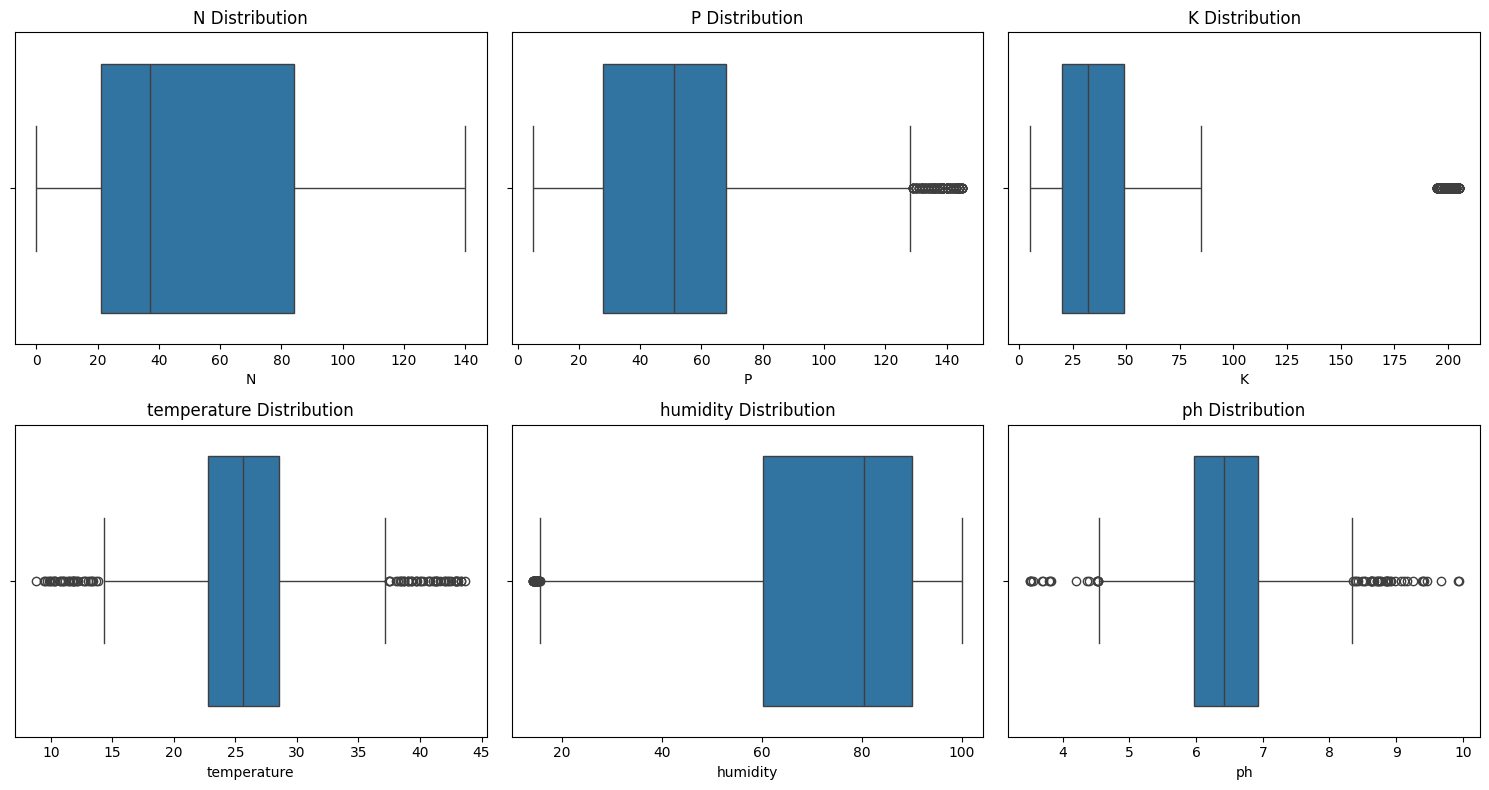

In [32]:
# Feature-wise distribution crop ke hisaab se
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

for i, col in enumerate(features[:6]):
    sns.boxplot(x=df[col], ax=axes[i//3][i%3])
    axes[i//3][i%3].set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()

### Step 5: Feature Correlation Heatmap

A heatmap shows how strongly each pair of features is related to each other.
- Values close to **+1** → strong positive correlation (both increase together)
- Values close to **-1** → strong negative correlation (one increases, other decreases)
- Values close to **0** → no relationship

**Why this matters:** If two features are highly correlated (e.g., 0.9+), they carry duplicate information and one could be dropped to simplify the model. In this dataset, most features are relatively independent, confirming all 7 features are worth keeping for training.

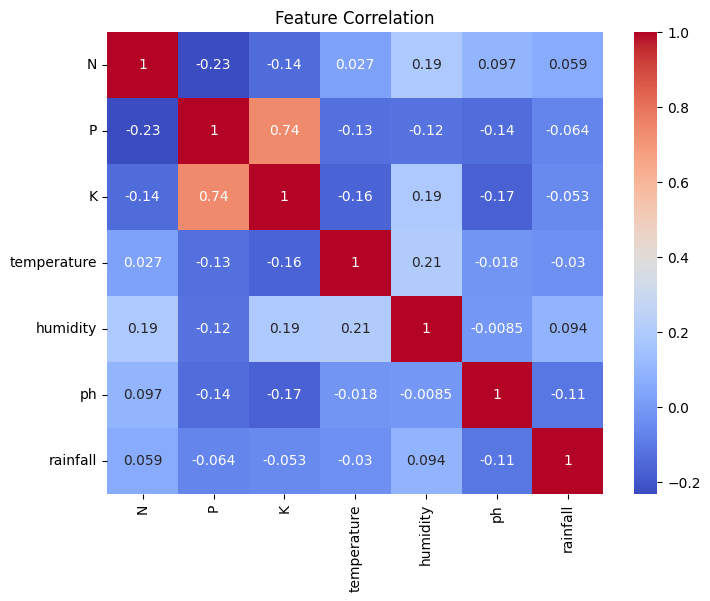

In [33]:
# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.drop('label', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

### Step 6: Label Encoding — Convert Crop Names to Numbers

Machine Learning models only understand numbers, not text. The `label` column contains crop names like "rice", "maize", "apple" etc.

`LabelEncoder` converts each unique crop name into a number:
- apple → 0, banana → 1, blackgram → 2 ... rice → 19 (alphabetical order)

A new column `crop_encode` is added to the DataFrame storing these numeric values.
`le.classes_` stores the mapping so we can later decode numbers back to crop names in the Flask app.

In [34]:
le = LabelEncoder()
df['crop_encode'] = le.fit_transform(df['label'])

# Verify karein
print("Classes:", le.classes_)
print("Encoded values:", df['crop_encode'].unique())

Classes: ['apple' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee' 'cotton'
 'grapes' 'jute' 'kidneybeans' 'lentil' 'maize' 'mango' 'mothbeans'
 'mungbean' 'muskmelon' 'orange' 'papaya' 'pigeonpeas' 'pomegranate'
 'rice' 'watermelon']
Encoded values: [20 11  3  9 18 13 14  2 10 19  1 12  7 21 15  0 16 17  4  6  8  5]


### Step 7: Separate Features (X) and Target (y)

We split the DataFrame into:
- **X (Features)** — the 7 input columns: N, P, K, temperature, humidity, ph, rainfall
  These are the soil and climate conditions we will give as input.
- **y (Target)** — the `crop_encode` column (numbers representing each crop)
  This is what the model will learn to predict.

Both original text label column and encoded column are dropped from X to avoid data leakage.
Result: X shape → (2200, 7) | y shape → (2200,)

In [35]:
X = df.drop(['label', 'crop_encode'], axis=1)   # 7 features
y = df['crop_encode']                             # target

print("X shape:", X.shape)   # (2200, 7)
print("y shape:", y.shape)   # (2200,)

X shape: (2200, 7)
y shape: (2200,)


### Step 8: Split Data into Training and Testing Sets

We divide the data into two parts:
- **80% Training data** (1760 samples) — model learns patterns from this
- **20% Testing data** (440 samples) — we evaluate model on this unseen data

Key parameters:
- `random_state=42` — ensures the same split every time we run the code (reproducibility)
- `stratify=y` — ensures each crop class is equally represented in both train and test sets (since we have 100 samples per crop, each split will have ~80 train and ~20 test per crop)

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,        # 80% train, 20% test
    random_state=42,      # reproducibility ke liye
    stratify=y            # har class equally split ho
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (1760, 7)
Test size: (440, 7)


### Step 9: Feature Scaling — StandardScaler

Different features have very different ranges:
- Nitrogen (N): 0–140
- pH: 3.5–10
- Rainfall: 20–300

If we don't scale, models like Logistic Regression will think high-value features (like Rainfall) are more important than low-value ones (like pH) — which is wrong.

StandardScaler transforms every feature to have mean=0 and standard deviation=1, putting all features on equal footing.

**Important:** We use `fit_transform` only on training data (learns the scale from train), and only `transform` on test data. Fitting on test data would cause data leakage — the model would indirectly "see" test data during training, giving falsely high accuracy.

In [37]:
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)   # fit + transform on train
X_test_sc = sc.transform(X_test)         # sirf transform on test

### Step 10: Define Hyperparameter Grids for GridSearchCV

Instead of manually guessing the best settings for each model, we define a range of values to try automatically.

For each model, we specify:
- **Random Forest** — how many trees (50/100/200), how deep they go, minimum samples to split
- **Logistic Regression** — regularization strength (C), which math solver to use
- **Decision Tree** — tree depth, split criteria (gini vs entropy), minimum samples
- **Naive Bayes** — var_smoothing (controls how much smoothing is applied to probabilities)

GridSearchCV will try every combination and find the best one using cross-validation.

In [38]:
param_grids = {
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [50, 100, 200],
            "max_depth": [5, 10, None],
            "min_samples_split": [2, 5]
        }
    },
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000),
        "params": {
            "C": [0.1, 1, 10],
            "solver": ["lbfgs", "saga"]
        }
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "max_depth": [5, 10, 20, None],
            "min_samples_split": [2, 5, 10],
            "criterion": ["gini", "entropy"]
        }
    },
    "Naive Bayes": {
        "model": GaussianNB(),
        "params": {
            "var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]
        }
    }
}


### Step 11: Train All 4 Models with GridSearchCV

This is the core training block. For each model:

1. GridSearchCV tries every combination of hyperparameters defined in the param grid
2. For each combination, it performs **5-fold cross validation** — splits training data into 5 parts, trains on 4, validates on 1, repeats 5 times and averages the score
3. The combination with highest average CV accuracy is selected as `best_estimator_`
4. We then predict on the test set and calculate final test accuracy

`n_jobs=-1` uses all CPU cores in parallel to speed up the search significantly.

This process ensures we are not just finding a model that memorizes training data, but one that genuinely generalizes well to new unseen data.

In [39]:
results = {}
best_models = {}

for name, config in param_grids.items():
    print(f"\n Searching best params for: {name} ...")
    
    grid = GridSearchCV(
        estimator=config["model"],
        param_grid=config["params"],
        cv=5,                    # 5-fold cross validation
        scoring="accuracy",      # accuracy ke basis pe best dhundo
        n_jobs=-1,               # saare CPU cores use karo (fast)
        verbose=1                # progress dikhao
    )
    
    grid.fit(X_train_sc, y_train)
    
    # Best model se predict karo
    y_pred = grid.best_estimator_.predict(X_test_sc)
    acc = accuracy_score(y_test, y_pred)
    
    results[name] = {
        "best_params": grid.best_params_,
        "cv_best_score": round(grid.best_score_ * 100, 2),
        "test_accuracy": round(acc * 100, 2)
    }
    
    best_models[name] = grid.best_estimator_
    
    print(f" {name} Done!")
    print(f"   Best Params : {grid.best_params_}")
    print(f"   CV Accuracy : {grid.best_score_*100:.2f}%")
    print(f"   Test Accuracy: {acc*100:.2f}%")


 Searching best params for: Random Forest ...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
 Random Forest Done!
   Best Params : {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
   CV Accuracy : 99.60%
   Test Accuracy: 99.55%

 Searching best params for: Logistic Regression ...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
 Logistic Regression Done!
   Best Params : {'C': 10, 'solver': 'lbfgs'}
   CV Accuracy : 97.84%
   Test Accuracy: 97.73%

 Searching best params for: Decision Tree ...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
 Decision Tree Done!
   Best Params : {'criterion': 'gini', 'max_depth': 20, 'min_samples_split': 5}
   CV Accuracy : 98.52%
   Test Accuracy: 97.95%

 Searching best params for: Naive Bayes ...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
 Naive Bayes Done!
   Best Params : {'var_smoothing': 1e-09}
   CV Accuracy : 99.43%
   Test Accuracy: 99.55%


### Step 12: Compare All Models

We display a summary table showing for each model:
- **best_params** — the winning hyperparameter combination found by GridSearchCV
- **cv_best_score** — average accuracy across 5 cross-validation folds (more reliable)
- **test_accuracy** — accuracy on the held-out 20% test data

This table lets us objectively compare all 4 models and make a data-driven decision about which one to deploy.

In [40]:
print("\n\n FINAL COMPARISON TABLE")
print("="*60)
results_df = pd.DataFrame(results).T
print(results_df.to_string())



 FINAL COMPARISON TABLE
                                                                        best_params cv_best_score test_accuracy
Random Forest        {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}          99.6         99.55
Logistic Regression                                    {'C': 10, 'solver': 'lbfgs'}         97.84         97.73
Decision Tree        {'criterion': 'gini', 'max_depth': 20, 'min_samples_split': 5}         98.52         97.95
Naive Bayes                                                {'var_smoothing': 1e-09}         99.43         99.55


### Step 13: Automatically Select the Best Model

Instead of manually reading the table and deciding, we programmatically find the model with the highest test accuracy using Python's `max()` function.

The winning model name and its best hyperparameters are printed clearly.
This model object (`best_model`) will be used for the classification report and saving to disk.

In [41]:
best_model_name = max(results, key=lambda x: results[x]["test_accuracy"])
best_model = best_models[best_model_name]

print(f"\n\n BEST MODEL: {best_model_name}")
print(f"   Accuracy: {results[best_model_name]['test_accuracy']}%")
print(f"   Best Params: {results[best_model_name]['best_params']}")



 BEST MODEL: Random Forest
   Accuracy: 99.55%
   Best Params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}


### Step 14: Detailed Classification Report of Best Model

Accuracy alone is not enough — it only tells us the overall % correct. The classification report gives a deeper view for each individual crop:

- **Precision** — of all times the model predicted "rice", how many were actually rice?
- **Recall** — of all actual rice samples, how many did the model correctly identify?
- **F1-Score** — harmonic mean of precision and recall (overall per-class performance)
- **Support** — how many actual samples of each crop were in the test set

A model with 99%+ precision and recall across all 22 crops is considered production-ready and reliable enough to deploy in a Flask web application.

In [42]:
y_pred_best = best_model.predict(X_test_sc)
print(f"\n Classification Report — {best_model_name}:")
print(classification_report(y_test, y_pred_best, target_names=le.classes_))


 Classification Report — Random Forest:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1

### Step 15: Save Model, Scaler and Label Encoder

We save three essential files using Python's pickle module into the `models/` folder:

- **model.pkl** — the trained best model; used to make predictions in Flask app
- **scaler.pkl** — the fitted StandardScaler; must be applied to new input data before prediction (same scaling as training)
- **label_encoder.pkl** — the fitted LabelEncoder; converts predicted number back to crop name (e.g., 19 → "rice") for displaying in the web app

All three files must be saved together. Missing any one will break the Flask prediction pipeline.

In [44]:
pickle.dump(best_model, open('models/model.pkl', 'wb'))
pickle.dump(sc, open('models/scaler.pkl', 'wb'))
pickle.dump(le, open('models/label_encoder.pkl', 'wb'))
pickle.dump(df, open('models/df.pkl', 'wb'))

print("\nModel saved successfully!")
print("Model file: models/model.pkl")
print("Scaler file: models/scaler.pkl")
print("Label Encoder file: models/label_encoder.pkl")
print("Data file: models/df.pkl")


Model saved successfully!
Model file: models/model.pkl
Scaler file: models/scaler.pkl
Label Encoder file: models/label_encoder.pkl
Data file: models/df.pkl
